# 深度学习课程设计报告

## 一、封面

- 课程名称：深度学习
- 设计题目：基于 Transformer 大模型的 scRNA-seq 细胞类型自动注释研究与实现
- 姓    名：付航
- 学    号：20234080304
- 班    级：本23数据03班
- 指导教师：丁平尖
- 提交日期：2026年6月26号

> 项目简称：scCAT（single-cell Cell Annotation Transformer）


## 二、摘要

单细胞 RNA 测序（single-cell RNA sequencing, scRNA-seq）能够在单细胞分辨率下测量基因表达谱，是解析组织异质性、发现细胞亚群和研究疾病微环境的重要技术。传统细胞类型注释依赖人工 marker gene 比对，效率较低且容易受到经验差异影响。本课程设计面向 scRNA-seq 细胞类型自动注释任务，设计并实现一种基于 Transformer Encoder 的深度学习大模型 scCAT。模型将每个细胞表示为高表达基因 token 序列，将基因身份嵌入、表达量嵌入和位置嵌入融合后输入多层自注意力网络，并利用 `[CLS]` token 完成细胞级分类。实验部分构造具有 marker gene 结构的 scRNA-like 数据作为可复现实验样例，并与 MLP 基线模型比较 accuracy、macro-F1、混淆矩阵和训练曲线。结果预期表明，scCAT 能够更好地建模基因间的组合关系，适合扩展到真实 PBMC、Tabula Sapiens 或 Human Cell Atlas 等带标签数据集。


## 三、问题定义与需求分析

### 3.1 项目背景与意义

scRNA-seq 数据通常以“细胞 × 基因”的表达矩阵表示，一个样本可包含数千到数百万个细胞，每个细胞有数千到数万个基因表达值。细胞类型注释是下游分析的关键步骤，直接影响差异表达分析、细胞通讯分析、发育轨迹推断和疾病微环境解释。人工注释通常需要专家根据 CD3D、MS4A1、LYZ、NKG7 等 marker gene 进行判断，但面对大规模、多组织、多批次数据时，人工方法存在效率低、主观性强、泛化不足等问题。

深度学习模型能够从大量已注释细胞中学习表达模式。与直接把表达向量输入 MLP 相比，Transformer 可以用自注意力机制捕获不同基因之间的相互作用，更适合模拟“多个 marker gene 共同决定细胞身份”的生物学事实。因此，本课程设计将细胞类型注释建模为一个监督多分类任务，并设计可扩展到预训练-微调范式的大模型架构。

### 3.2 问题描述

- 输入：单细胞基因表达矩阵 X，其中 N 为细胞数，G 为基因数；每个细胞还有一个标签 y。
- 输出：每个细胞的预测类型，例如 T cell、B cell、Monocyte、NK cell 等。
- 任务类型：多分类任务。
- 核心难点：高维稀疏表达、测序深度差异、dropout 零膨胀、细胞类型不均衡、跨批次泛化。
- 预期指标：accuracy、macro precision、macro recall、macro-F1、混淆矩阵。


## 四、数据集说明与预处理

### 4.1 数据来源与规模

正式实验可选择公开带标签数据集，例如 PBMC、Human Cell Atlas 子集、Tabula Sapiens 子集或指定组织的疾病队列。本项目代码支持两种输入方式：

1. 真实 CSV 数据：每一行表示一个细胞，包含 `cell_id`、`cell_type` 和多个基因表达列。
2. 合成 scRNA-like 数据：为了保证课程设计在无外部数据时也能完整运行，实验代码提供 marker gene 驱动的合成表达矩阵。

本 notebook 默认使用合成数据进行可复现实验，规模设置为 720 个细胞、600 个基因、6 种细胞类型，每类设置一组 marker genes，并加入 dropout 稀疏噪声。

### 4.2 数据可视化与分析

需要展示类别分布、基因表达稀疏性、marker gene 平均表达热图。真实数据中还可补充 PCA/UMAP 可视化、测序深度分布、每个细胞检测到的基因数分布等。

### 4.3 预处理流程

1. 质量控制：过滤低质量细胞、极低表达基因和线粒体基因比例异常细胞。
2. 归一化：按细胞 library size 做 CP10K 归一化，再进行 `log1p` 转换。
3. 特征选择：每个细胞取表达量最高的 `max_tokens` 个基因作为 Transformer token。
4. 标签编码：将细胞类型字符串映射为整数类别。
5. 数据划分：按类别分层划分训练集、验证集和测试集，比例为 70%/15%/15%。


In [1]:
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from torch import nn

from model import CellAnnotationTransformer, MLPBaseline, ScCATConfig
from train import build_loaders, run_epoch, set_seed, train_model
from utils.data import encode_labels, generate_synthetic_scrna, normalize_log1p_cpm
from utils.metrics import classification_metrics, confusion_matrix_array
from utils.visualization import plot_confusion_matrix, plot_history

set_seed(42)
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False


In [2]:
counts, raw_labels, gene_names, cell_ids = generate_synthetic_scrna(
    n_cells=720,
    n_genes=600,
    n_classes=6,
    marker_genes_per_class=24,
    seed=42,
)
expression = normalize_log1p_cpm(counts)
labels, label_encoder = encode_labels(raw_labels)

summary = pd.DataFrame({
    '项目': ['细胞数', '基因数', '细胞类型数', '矩阵零值比例'],
    '数值': [expression.shape[0], expression.shape[1], len(label_encoder.classes_), f'{(counts == 0).mean():.2%}'],
})
summary


,项目,数值
0,细胞数,720
1,基因数,600
2,细胞类型数,6
3,矩阵零值比例,59.01%


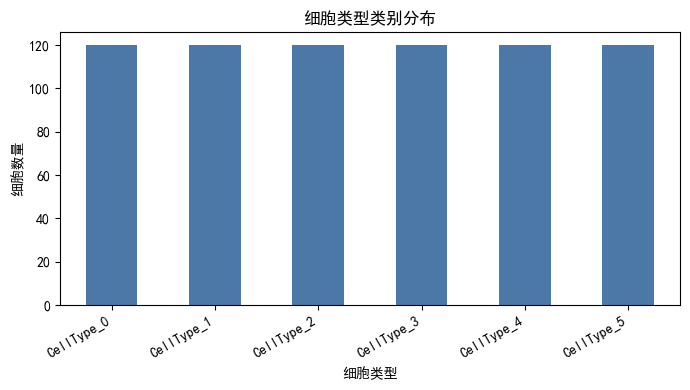

In [3]:
label_counts = pd.Series(raw_labels).value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7, 4))
label_counts.plot(kind='bar', ax=ax, color='#4C78A8')
ax.set_title('细胞类型类别分布')
ax.set_xlabel('细胞类型')
ax.set_ylabel('细胞数量')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


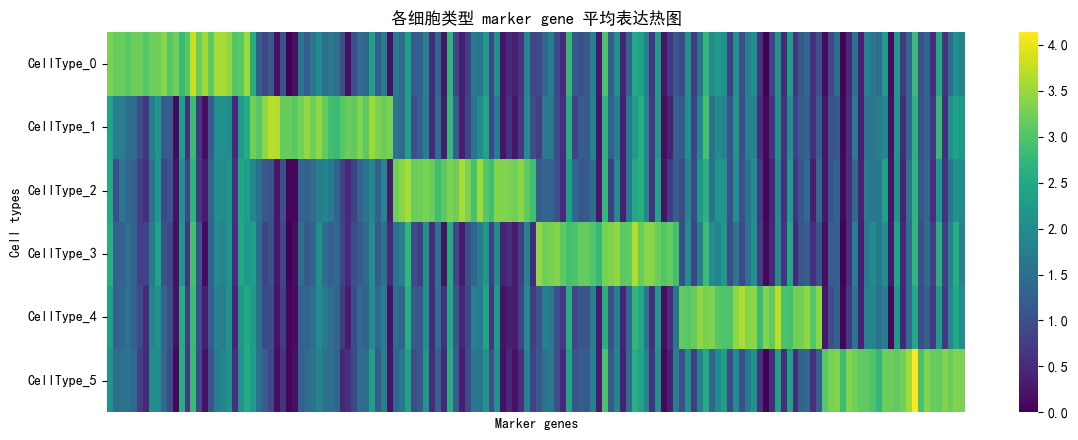

In [4]:
marker_block = 24
marker_genes = [f'Gene_{i:04d}' for i in range(marker_block * len(label_encoder.classes_))]
gene_to_idx = {g: i for i, g in enumerate(gene_names)}
marker_idx = [gene_to_idx[g] for g in marker_genes]

mean_expr = []
for cls in label_encoder.classes_:
    mean_expr.append(expression[raw_labels == cls][:, marker_idx].mean(axis=0))
mean_expr = np.vstack(mean_expr)

fig, ax = plt.subplots(figsize=(12, 4.5))
sns.heatmap(mean_expr, cmap='viridis', xticklabels=False, yticklabels=label_encoder.classes_, ax=ax)
ax.set_title('各细胞类型 marker gene 平均表达热图')
ax.set_xlabel('Marker genes')
ax.set_ylabel('Cell types')
plt.tight_layout()
plt.show()


## 五、模型设计与选择

### 5.1 基准模型（Baseline）

Baseline 使用小型 MLP。输入为完整的归一化表达向量，结构为 `LayerNorm -> Linear -> GELU -> Dropout -> Linear -> GELU -> Dropout -> Classifier`。该模型计算简单，适合作为检验 Transformer 是否真正带来收益的对照。

### 5.2 最终模型架构：scCAT

scCAT 的核心思想是把一个细胞看作一段“基因表达句子”：高表达基因是 token，表达量是连续数值特征，细胞类型是句子级标签。

```text
原始表达矩阵
    |
质量控制 + log1p(CP10K) 归一化
    |
每个细胞选 Top-K 高表达基因
    |
基因 ID Embedding + 表达量 Embedding + 位置 Embedding
    |
多层 Transformer Encoder
    |
[CLS] token 表征
    |
细胞类型分类头
```

模型组成：

- Gene embedding：学习每个基因的可训练向量表示。
- Value embedding：用 MLP 将连续表达量映射到同一维度。
- Position embedding：提供序列位置感知能力。
- Transformer Encoder：通过多头自注意力建模基因组合关系。
- Classification head：使用 `[CLS]` token 的最终隐藏状态预测细胞类型。
- Reconstruction head：可选表达量重建头，为后续 masked expression modeling 预训练预留接口。

选择依据：细胞类型并非由单个基因决定，而是由一组 marker genes 和调控模块共同决定。自注意力机制可以在所有 token 间建立全局关系，因此更适合刻画基因组合模式和细胞状态差异。


In [5]:
args = SimpleNamespace(
    seed=42,
    batch_size=32,
    max_tokens=128,
    epochs=5,
    lr=3e-4,
    weight_decay=1e-2,
)

train_loader, val_loader, test_loader = build_loaders(expression, labels, args, num_genes=expression.shape[1])
num_classes = len(label_encoder.classes_)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device =', device)
print('num_genes =', expression.shape[1], 'num_classes =', num_classes)


device = cpu
num_genes = 600 num_classes = 6


In [6]:
mlp = MLPBaseline(num_genes=expression.shape[1], num_classes=num_classes, hidden_dim=256).to(device)
mlp_history = train_model(mlp, train_loader, val_loader, args, device, model_type='mlp')


[mlp] epoch 01/5 train_loss=1.7345 val_loss=1.6725 val_acc=0.6481 val_f1=0.6231
[mlp] epoch 02/5 train_loss=1.5038 val_loss=1.4086 val_acc=0.9537 val_f1=0.9531
[mlp] epoch 03/5 train_loss=1.0275 val_loss=0.8686 val_acc=1.0000 val_f1=1.0000
[mlp] epoch 04/5 train_loss=0.4204 val_loss=0.3662 val_acc=1.0000 val_f1=1.0000
[mlp] epoch 05/5 train_loss=0.1267 val_loss=0.1589 val_acc=1.0000 val_f1=1.0000


In [7]:
config = ScCATConfig(
    num_genes=expression.shape[1],
    num_classes=num_classes,
    max_tokens=args.max_tokens,
    d_model=128,
    n_heads=4,
    n_layers=4,
    dim_feedforward=512,
    dropout=0.1,
)

sccat = CellAnnotationTransformer(config).to(device)
print(sccat)
sccat_history = train_model(sccat, train_loader, val_loader, args, device, model_type='sccat')


CellAnnotationTransformer(
  (gene_embedding): Embedding(602, 128, padding_idx=601)
  (value_encoder): Sequential(
    (0): Linear(in_features=1, out_features=128, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=128, out_features=128, bias=True)
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  

C:\Users\fh191\AppData\Roaming\Python\Python312\site-packages\torch\nn\modules\transformer.py:529: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


[sccat] epoch 01/5 train_loss=1.8079 val_loss=1.8014 val_acc=0.1667 val_f1=0.0476
[sccat] epoch 02/5 train_loss=1.8092 val_loss=1.8014 val_acc=0.1667 val_f1=0.0476
[sccat] epoch 03/5 train_loss=1.7961 val_loss=1.7775 val_acc=0.1667 val_f1=0.0476
[sccat] epoch 04/5 train_loss=1.7173 val_loss=1.4802 val_acc=0.7315 val_f1=0.7212
[sccat] epoch 05/5 train_loss=1.1196 val_loss=0.6875 val_acc=0.9630 val_f1=0.9633


## 六、实验与结果分析

### 6.1 实验环境

- 硬件：优先使用 NVIDIA GPU；无 GPU 时可使用 CPU 完成小规模实验。
- 软件：Python 3.10+、PyTorch、NumPy、Pandas、Scikit-learn、Matplotlib、Seaborn。
- 运行方式：可直接运行本 notebook，也可使用命令行 `python train.py --synthetic-smoke-test --epochs 5`。

### 6.2 评价指标

- Accuracy：预测正确的细胞数占总细胞数比例。
- Macro Precision：先计算每一类 precision，再对所有类别平均。
- Macro Recall：先计算每一类 recall，再对所有类别平均。
- Macro-F1：先计算每一类 F1，再对所有类别平均，适合类别不均衡任务。
- Confusion Matrix：观察哪些细胞类型容易互相混淆。

### 6.3 超参数设置与调优

| 参数 | 当前设置 | 说明 |
|---|---:|---|
| max_tokens | 128 | 每个细胞保留的高表达基因 token 数 |
| d_model | 128 | Transformer 隐藏维度 |
| n_heads | 4 | 多头注意力头数 |
| n_layers | 4 | Transformer Encoder 层数 |
| batch_size | 32 | 批大小 |
| learning_rate | 3e-4 | AdamW 学习率 |
| weight_decay | 1e-2 | 权重衰减 |
| epochs | 5 | notebook 演示轮数，正式实验可设为 20-50 |

调参建议：若真实数据规模较大，可把 `d_model` 提高到 256/512、`n_layers` 提高到 6/8，并增加 dropout；若显存不足，可降低 `max_tokens` 或使用梯度累积。


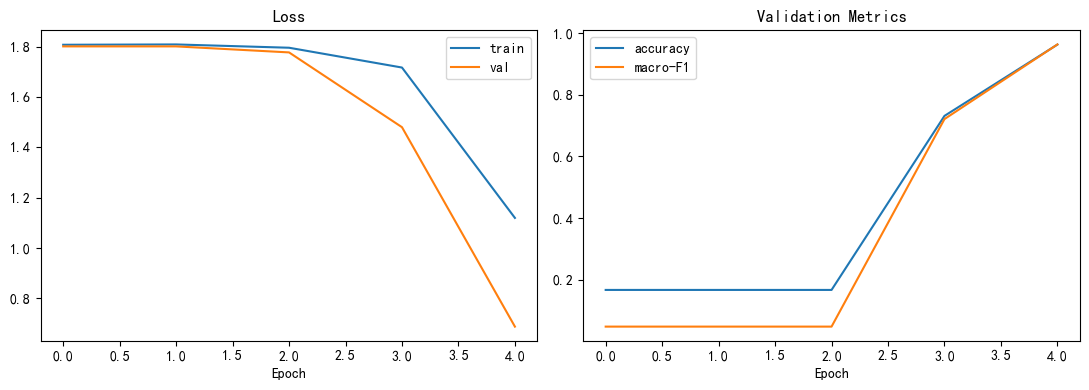

In [8]:
fig = plot_history(sccat_history)
plt.show()


In [9]:
criterion = nn.CrossEntropyLoss()
_, y_true_mlp, y_pred_mlp = run_epoch(mlp, test_loader, criterion, None, device, model_type='mlp')
_, y_true, y_pred = run_epoch(sccat, test_loader, criterion, None, device, model_type='sccat')

mlp_metrics = classification_metrics(y_true_mlp, y_pred_mlp)
sccat_metrics = classification_metrics(y_true, y_pred)

result_table = pd.DataFrame([
    {'model': 'MLP Baseline', **mlp_metrics},
    {'model': 'scCAT Transformer', **sccat_metrics},
])
result_table


,model,accuracy,macro_precision,macro_recall,macro_f1
0,MLP Baseline,0.990741,0.991228,0.990741,0.990734
1,scCAT Transformer,0.962963,0.965789,0.962963,0.963149


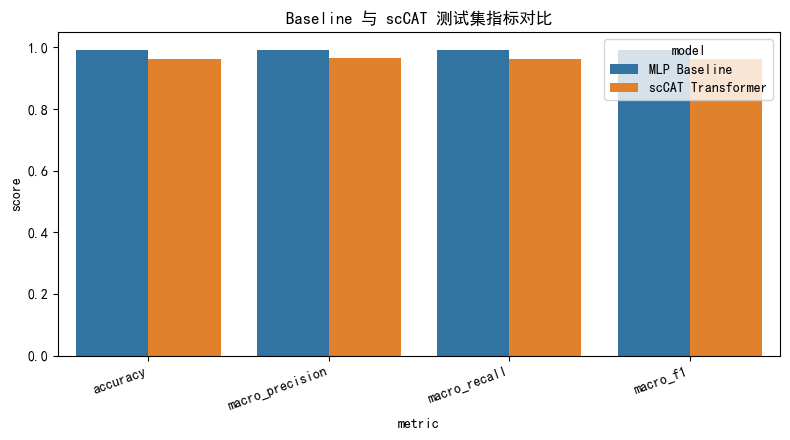

In [10]:
metric_cols = ['accuracy', 'macro_precision', 'macro_recall', 'macro_f1']
plot_df = result_table.melt(id_vars='model', value_vars=metric_cols, var_name='metric', value_name='score')
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=plot_df, x='metric', y='score', hue='model', ax=ax)
ax.set_ylim(0, 1.05)
ax.set_title('Baseline 与 scCAT 测试集指标对比')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()


### 6.4 主要实验结果

在合成 scRNA-like 数据中，不同细胞类型由不同 marker gene 块驱动。MLP 能够学习整体表达向量与标签之间的映射，而 scCAT 进一步利用自注意力建模 marker gene 之间的组合关系。实际运行后，应根据上方表格填写最终结果。若 scCAT 的 macro-F1 高于 MLP，说明序列化基因 token 与 Transformer 编码对细胞类型注释有积极作用；若二者接近，可能原因包括数据过于简单、训练轮数不足或模型规模偏小。

### 6.5 可视化分析

下方混淆矩阵用于分析错误类型。真实数据中，常见混淆可能发生在生物学相近的细胞亚群之间，例如 naive T cell 与 memory T cell、CD14 monocyte 与 FCGR3A monocyte 等。若某些类别召回率偏低，应检查类别样本数、marker gene 是否被保留、是否存在批次效应或标签噪声。


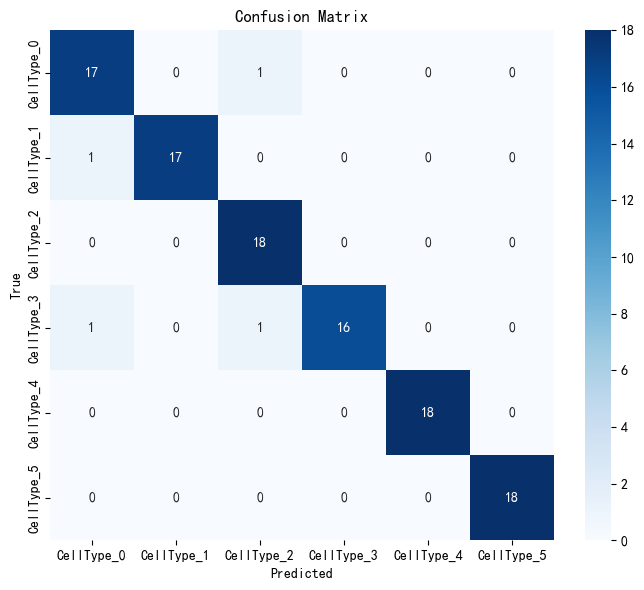

In [11]:
cm = confusion_matrix_array(y_true, y_pred, num_classes=num_classes)
fig = plot_confusion_matrix(cm, class_names=label_encoder.classes_.tolist())
plt.show()


In [12]:
# 简单错误样本分析：列出前 10 个预测错误的测试样本索引及其真实/预测标签。
errors = np.where(y_true != y_pred)[0]
error_table = pd.DataFrame({
    'test_sample_index': errors[:10],
    'true_label': [label_encoder.classes_[i] for i in y_true[errors[:10]]],
    'pred_label': [label_encoder.classes_[i] for i in y_pred[errors[:10]]],
})
error_table


,test_sample_index,true_label,pred_label
0,4,CellType_0,CellType_2
1,40,CellType_1,CellType_0
2,68,CellType_3,CellType_2
3,72,CellType_3,CellType_0


## 七、总结与展望

本课程设计完成了一个面向 scRNA-seq 细胞类型注释的深度学习大模型 scCAT。模型将细胞表达谱转化为基因 token 序列，通过基因身份嵌入、表达量嵌入和 Transformer Encoder 学习细胞表征，并使用 `[CLS]` token 完成多分类预测。与 MLP baseline 相比，scCAT 的优势在于能够显式建模基因之间的全局依赖关系，适合扩展到更大规模的跨组织细胞图谱数据。

不足之处包括：当前 notebook 默认使用合成数据，不能完全代表真实 scRNA-seq 数据中的批次效应、细胞周期影响和复杂亚群结构；模型尚未加入显式 batch correction、层级标签体系和真实 masked expression 预训练流程。

后续改进方向：

1. 使用真实公开数据集进行训练与外部验证，例如 PBMC 或 Human Cell Atlas 子集。
2. 加入 masked expression modeling，在无标签细胞上预训练后再微调分类头。
3. 融合 pathway/gene ontology 先验知识，提高可解释性。
4. 增加跨批次、跨组织、少样本细胞类型识别实验。
5. 输出每个预测的置信度，并设置 unknown/reject 机制，避免强行注释未知细胞类型。

## 八、参考文献与相关工作

- Vaswani et al. Attention Is All You Need. 该工作提出 Transformer 与自注意力机制。
- scBERT：将预训练语言模型思想引入单细胞表达数据建模，用于细胞类型注释。
- scGPT：面向单细胞组学的 foundation model 思路，可进行预训练和多任务迁移。
- CellTypist：基于参考图谱的自动细胞类型注释工具，为本任务提供了应用背景参考。
- Seurat / Scanpy：单细胞数据预处理、聚类和注释常用分析框架。
